In [1]:
# Classified Dataset 

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [3]:
# Getting the data 
theeData = pd.read_csv('Classified Data', index_col=0)

In [29]:
theeData.head() 

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [8]:
# Standardising the variables ? 

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler() 

In [12]:
scaler.fit(theeData.drop('TARGET CLASS', axis=1))

StandardScaler()

In [13]:
scaled_features = scaler.transform(theeData.drop('TARGET CLASS', axis=1))

In [14]:
data_features = pd.DataFrame(scaled_features, columns=theeData.columns[:-1])

In [15]:
data_features.head() 

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


In [16]:
# Train Test Split 

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(scaled_features, theeData['TARGET CLASS'], test_size=0.30)

In [19]:
# Using KNN Algorithm 

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
knn = KNeighborsClassifier(n_neighbors=1)

In [22]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [23]:
predictions = knn.predict(X_test)

In [24]:
# Predictions and Evaluations 

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
print(confusion_matrix(y_test, predictions))

[[128  20]
 [ 12 140]]


In [27]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.91      0.86      0.89       148
           1       0.88      0.92      0.90       152

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



In [32]:
# Choosing a K-Value 
error_rate = [] 

for i in range(1, 40): 

    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train) 
    pred_i = knn.predict(X_test) 
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

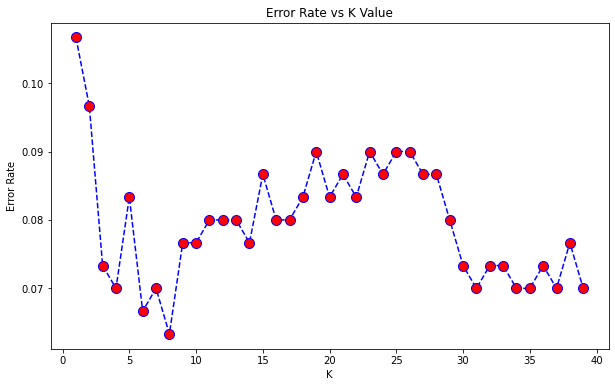

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate,color='blue', linestyle='dashed', 
marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [34]:
# Observations above 
# After K>23
# Error rate tends to hover around 0.07 - 0.09 

In [35]:
# Retrain the model 

In [36]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train) 
pred = knn.predict(X_test) 

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test, pred))
print('\n')
print(classification_report(y_test, pred))

WITH K=1


[[128  20]
 [ 12 140]]


              precision    recall  f1-score   support

           0       0.91      0.86      0.89       148
           1       0.88      0.92      0.90       152

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



In [37]:
# make K=23 
knn = KNeighborsClassifier(n_neighbors=23)

knn.fit(X_train, y_train) 
pred = knn.predict(X_test) 

print('WITH K=1')
print('\n')
print(confusion_matrix(y_test, pred))
print('\n')
print(classification_report(y_test, pred))

WITH K=1


[[127  21]
 [  6 146]]


              precision    recall  f1-score   support

           0       0.95      0.86      0.90       148
           1       0.87      0.96      0.92       152

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300



In [ ]:
# DONE. 